In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)

Repo root: C:\Users\llr\regime-filtered-momentum


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_ingest import load_ohlcv
from src.model_regime import generate_regime_probabilities, REGIME_ORDER
from src.signals import six_month_momentum_signal, regime_filtered_signal
from src.strategy import positions_from_signal
from src.backtest import run_backtest
from src.metrics import summarize_backtest
from src.config import CFG

In [3]:
df = load_ohlcv()

regime_df = generate_regime_probabilities(df)
data = regime_df.copy()
data["Close"] = df["Close"].reindex(data.index)

data["momentum_signal"] = six_month_momentum_signal(data)
data["filtered_signal"] = regime_filtered_signal(data)

data["momentum_position"] = positions_from_signal(data["momentum_signal"])
data["filtered_position"] = positions_from_signal(data["filtered_signal"])

bt_momentum = run_backtest(data, data["momentum_position"])
bt_filtered = run_backtest(data, data["filtered_position"])

In [4]:
summary = pd.concat(
    [
        summarize_backtest(bt_momentum).rename("momentum"),
        summarize_backtest(bt_filtered).rename("filtered"),
    ],
    axis=1,
)

summary

,momentum,filtered
annualized_return,0.070582,0.103986
annualized_volatility,0.115041,0.079332
sharpe_ratio,0.613535,1.310772
max_drawdown,-0.239524,-0.156549
turnover,0.026970,0.051454
exposure,0.745792,0.565991
number_of_trades,141.000000,269.000000


In [5]:
spy_returns = data["Close"].pct_change().fillna(0)
spy_equity = (1 + spy_returns).cumprod()

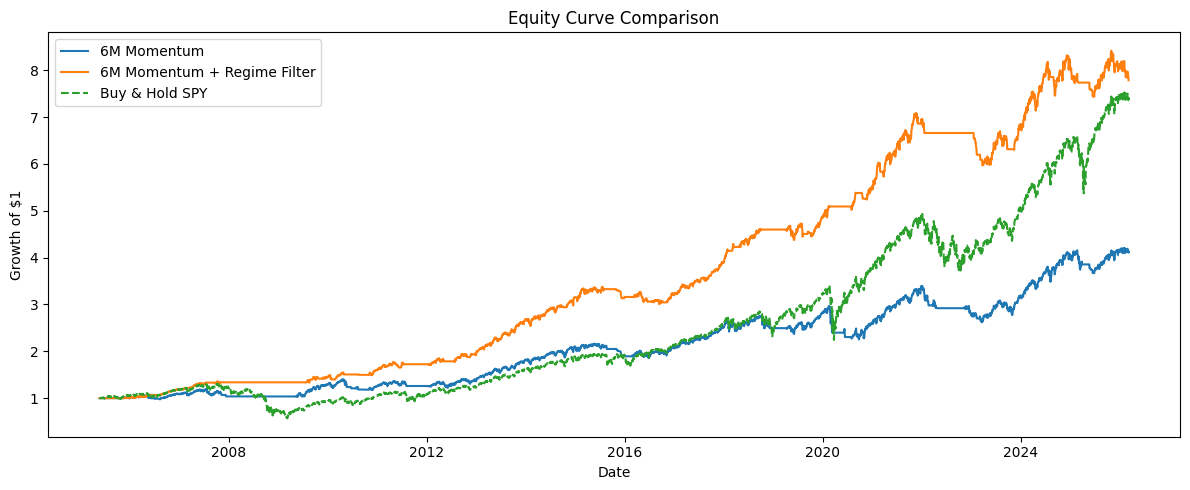

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(bt_momentum.index, bt_momentum["equity_curve"], label="6M Momentum")
plt.plot(bt_filtered.index, bt_filtered["equity_curve"], label="6M Momentum + Regime Filter")
plt.plot(spy_equity.index, spy_equity, label="Buy & Hold SPY", linestyle="--")

plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

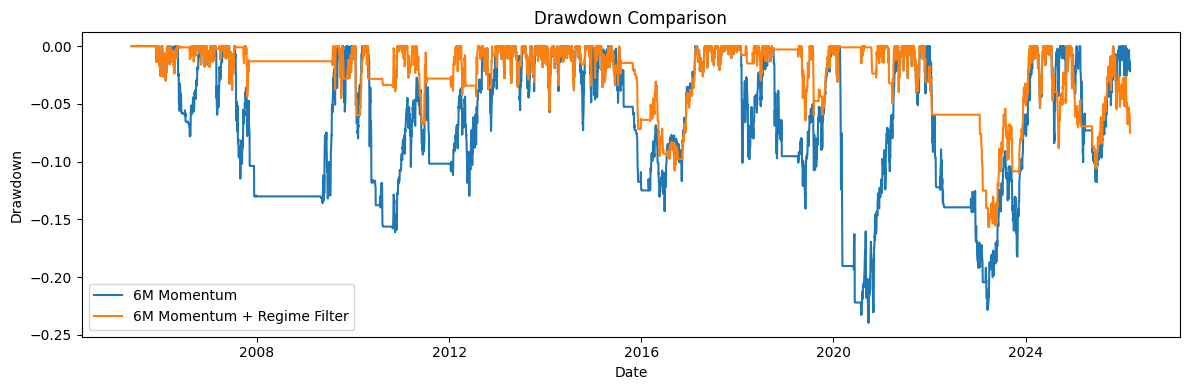

In [7]:
def compute_drawdown(equity_curve):
    running_max = equity_curve.cummax()
    return equity_curve / running_max - 1

bt_momentum["drawdown"] = compute_drawdown(bt_momentum["equity_curve"])
bt_filtered["drawdown"] = compute_drawdown(bt_filtered["equity_curve"])

plt.figure(figsize=(12, 4))
plt.plot(bt_momentum.index, bt_momentum["drawdown"], label="6M Momentum")
plt.plot(bt_filtered.index, bt_filtered["drawdown"], label="6M Momentum + Regime Filter")
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()

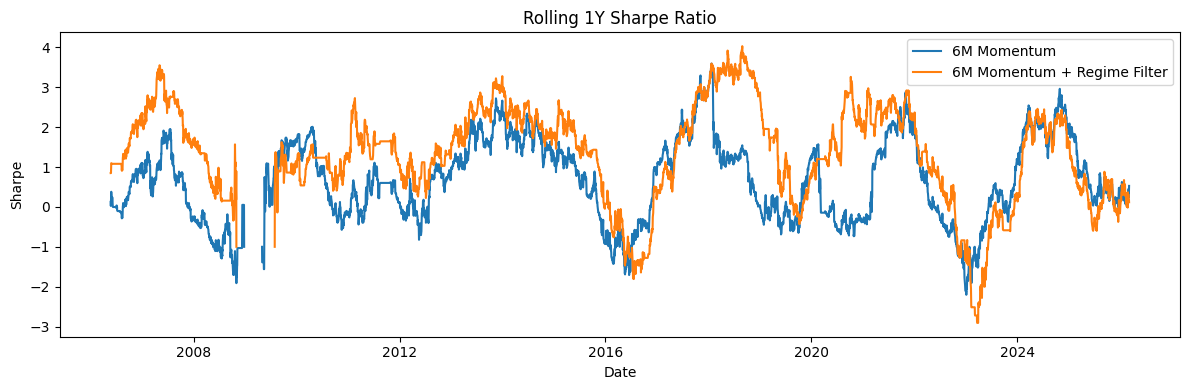

In [8]:
def rolling_sharpe(returns, window=252):
    rolling_mean = returns.rolling(window).mean() * 252
    rolling_std = returns.rolling(window).std() * np.sqrt(252)
    return rolling_mean / rolling_std

plt.figure(figsize=(12, 4))
plt.plot(bt_momentum.index, rolling_sharpe(bt_momentum["net_strategy_return"]), label="6M Momentum")
plt.plot(bt_filtered.index, rolling_sharpe(bt_filtered["net_strategy_return"]), label="6M Momentum + Regime Filter")
plt.title("Rolling 1Y Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
momentum_yearly = bt_momentum["net_strategy_return"].resample("YE").apply(lambda x: (1 + x).prod() - 1)
filtered_yearly = bt_filtered["net_strategy_return"].resample("YE").apply(lambda x: (1 + x).prod() - 1)

yearly = pd.concat(
    [momentum_yearly.rename("momentum"), filtered_yearly.rename("filtered")],
    axis=1
)

yearly.index = yearly.index.year
yearly

,momentum,filtered
Date,,
2005,-0.006044,-0.006044
2006,0.094837,0.185643
2007,-0.047186,0.135194
2008,0.000000,0.000000
2009,0.236661,0.076152
2010,-0.024106,0.110772
2011,0.006287,0.077764
2012,0.096496,0.129355
2013,0.323273,0.382271


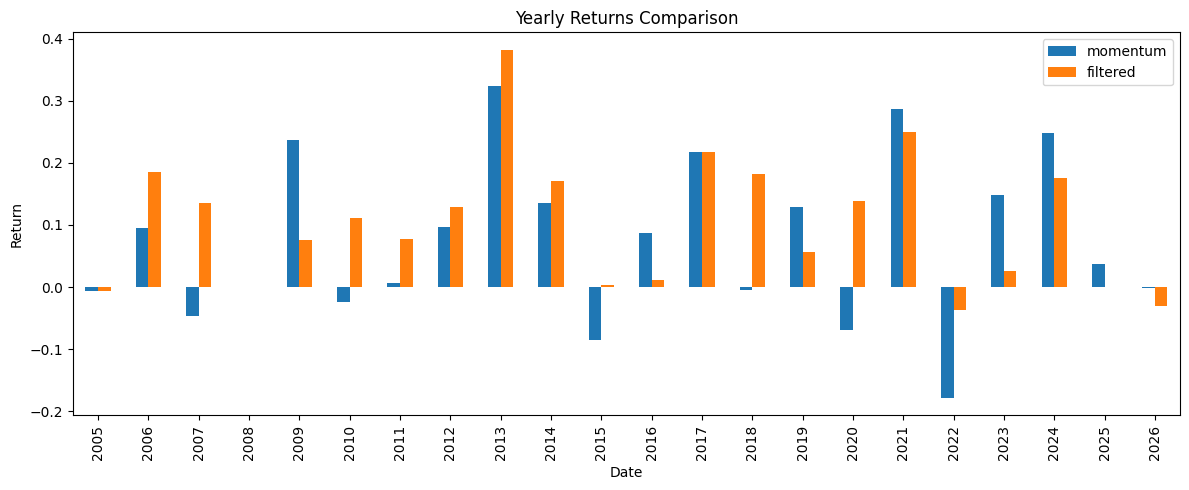

In [10]:
yearly.plot(kind="bar", figsize=(12, 5))
plt.title("Yearly Returns Comparison")
plt.ylabel("Return")
plt.tight_layout()
plt.show()

In [11]:
thresholds = [0.5, 0.6, 0.7, 0.8]
results = []

for threshold in thresholds:
    temp = regime_df.copy()
    temp["Close"] = df["Close"].reindex(temp.index)

    temp["momentum_signal"] = six_month_momentum_signal(temp)

    regime_filter = (temp["bull_calm"] > threshold).astype(int)
    temp["filtered_signal"] = (temp["momentum_signal"] * regime_filter).astype(int)

    temp["filtered_position"] = positions_from_signal(temp["filtered_signal"])

    bt = run_backtest(temp, temp["filtered_position"])
    metrics = summarize_backtest(bt)

    results.append({
        "threshold": threshold,
        **metrics.to_dict()
    })

threshold_results = pd.DataFrame(results)
threshold_results

print("Backtest start:", data.index.min())
print("Backtest end:", data.index.max())
print("Total days:", len(data))
print("Years:", len(data) / 252)

Backtest start: 2005-05-23 00:00:00
Backtest end: 2026-03-05 00:00:00
Total days: 5228
Years: 20.746031746031747


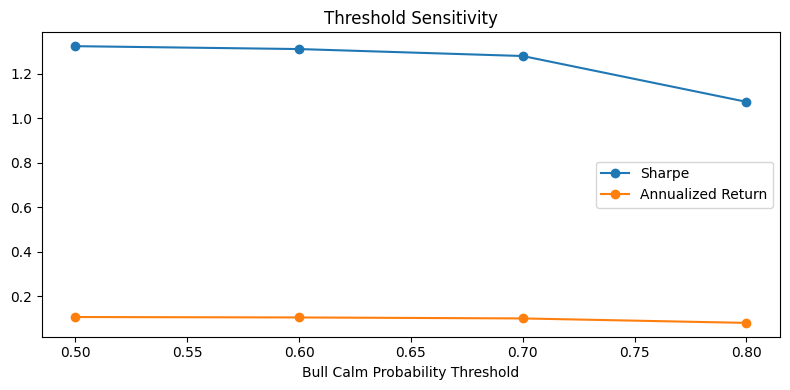

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_results["threshold"], threshold_results["sharpe_ratio"], marker="o", label="Sharpe")
plt.plot(threshold_results["threshold"], threshold_results["annualized_return"], marker="o", label="Annualized Return")
plt.title("Threshold Sensitivity")
plt.xlabel("Bull Calm Probability Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
trade_days = data["filtered_position"].diff().fillna(0) != 0
data.loc[trade_days, ["Close", "bull_calm", "momentum_signal", "filtered_signal"]].head(20)

,Close,bull_calm,momentum_signal,filtered_signal
Date,,,,
2005-11-21,97.0026,1.000,1,1
2006-04-05,101.0710,0.974,1,1
2006-04-06,100.9430,0.972,1,1
2006-05-11,101.0130,0.302,1,0
2006-05-25,98.5528,0.760,1,1
2006-05-30,97.2411,0.082,0,0
2006-08-07,98.7251,0.804,1,1
2007-02-23,112.1060,0.338,1,0
2007-03-21,110.5640,0.026,1,0
